# Investigating vegetation demographics with FATES

**BEFORE BEGINNING THIS EXERCISE** -  Check that your kernel (upper right corner, above) is `NPL 2023a`. This should be the default kernel, but if it is not, click on that button and select `NPL 2023a`.

_______________
This activity was developed primarily by Adrianna Foster.

## FATES output

As we described above, when run in higher complexity modes (i.e., not SP mode) FATES simulates more than just GPP and other biophysical fluxes. It also simulates vegetation demography (e.g., growth, allocation, competition, mortality, etc.) over time. This means we can look at really interesting outputs like vegetation structure (sizes and PFTs of trees), canopy closure, and successional dynamics.

We have already run a simulation at a NEON site: Bartlett Experimental Forest (**BART**). BART is a terrestrial NEON field site located within the Saco River Valley of the White Mountain National Forest in Carroll County, New Hampshire. Climate and glacial till soil make BART an ideal area for old-growth northern deciduous hardwoods consisting of beech (*Fagus sp.*) and sugar maple (*Acer saccarum*). White pines (*Pinus strobus*) are dispersed throughout the site but are primarily found in lower elevations. Softwood trees such as hemlock (*Tsuga canadensis*), balsam fir (*Abies balsamea*), and spruce are frequently found on cool steep slopes or in lower elevations with poor drainage.

For more information about this site, see the <a href="https://www.neonscience.org/field-sites/bart">NEON webpage</a> for it. 

For this simulation, we ran FATES in fixed biogeography mode, but ran two simulations:

1) with FATES initialized with inventory data from NEON and run for 10 years
2) with FATES run from bare ground and run for 100 years


For information on how to do inventory initialization with FATES, see the <a href='https://fates-users-guide.readthedocs.io/en/latest/user/Model-Initialization-Modes.html'>online documentation</a>.

*As before, start by loading some packages*

In [1]:
# python packages
import os
import glob
import xarray as xr
import numpy as np
import functools

# resources for plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
%matplotlib inline

### Helper functions

These are a few helper functions that we will use in this notebook.

In [2]:
def preprocess(data_set: xr.Dataset, data_vars: list[str]) -> xr.Dataset:
    """Preprocesses an xarray Dataset by subsetting to specific variables - to be used on read-in

    Args:
        data_set (xr.Dataset): input Dataset

    Returns:
        xr.Dataset: output Dataset
    """

    return data_set[data_vars]


def annual_sum(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes annual sum

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual sum output
    """

    months = raw_values["time.daysinmonth"]
    return conversion_factor * (months * raw_values).groupby("time.year").sum()


def annual_mean(raw_values: xr.DataArray, conversion_factor: float = 1.0) -> xr.DataArray:
    """Computes weighted annual mean using daysinmonth for missing-aware inputs.

    Args:
        raw_values (xr.DataArray): input raw data
        conversion_factor (float, optional): conversion factor. Defaults to 1.0

    Returns:
        xr.DataArray: annual mean output
    """

    months = raw_values["time.daysinmonth"]
    
    # multiply by number of days in month and conversion factor
    weighted = (raw_values * conversion_factor) * months

    # compute number of valid days per year
    valid_days = months.where(raw_values.notnull())

    # group and sum weighted data and valid days
    ann_sum = weighted.groupby("time.year").sum(dim="time", skipna=True)
    days_per_year = valid_days.groupby("time.year").sum(dim="time", skipna=True)

    return ann_sum / days_per_year.where(days_per_year > 0.0)

## 1. Reading and formatting data

**Note**: the drop-down solutions, below, assume you used i.fates.year1.a and i.fates.year1.a_vcmax output for plotting for this section.

---
## 3. 


### 3.1. Reading in the data

In [10]:
inv_file = "/glade/derecho/scratch/afoster/tutorial_output/i.fates.BART.nc"
bg_file = "/glade/derecho/scratch/afoster/tutorial_output/i.fates.BART.bareground.nc"

ds_inv = xr.open_dataset(inv_file).isel(lndgrid=0)
ds_bg = xr.open_dataset(bg_file).isel(lndgrid=0)

Because this is a single site, and not a regional or global run, we can just grab the one gridcell with `.sel(lndgrid=0)`, and we additionally don't need to multiply any of the FATES variables by `FATES_FRACTION`, because we just assume the gridcell is completely naturally vegetated.

In [11]:
# print information about the inventory-initialized dataset
ds_inv

<xarray.Dataset>
Dimensions:                         (fates_levscls: 13, fates_levage: 19,
                                     fates_levpft: 15, time: 120, nbnd: 2,
                                     fates_levscpf: 195)
Coordinates:
  * fates_levscls                   (fates_levscls) float32 0.0 5.0 ... 100.0
  * fates_levage                    (fates_levage) float32 0.0 5.0 ... 300.0
  * fates_levpft                    (fates_levpft) int32 1 2 3 4 ... 12 13 14 15
  * time                            (time) object 2000-01-16 12:00:00 ... 200...
Dimensions without coordinates: nbnd, fates_levscpf
Data variables: (12/25)
    time_bounds                     (time, nbnd) object ...
    EFLX_LH_TOT                     (time) float32 ...
    FATES_CANOPY_SPREAD             (time) float32 ...
    FATES_LAI                       (time) float32 ...
    FSH                             (time) float32 ...
    FATES_CANOPYAREA_AP             (time, fates_levage) float32 ...
    ...                              ...
    FATES_MORTALITY_TERMINATION_SZ  (time, fates_levscls) float32 ...
    FATES_PROMOTION_RATE_SZ         (time, fates_levscls) float32 ...
    FATES_DDBH_CANOPY_SZPF          (time, fates_levscpf) float32 ...
    FATES_NPLANT_CANOPY_SZPF        (time, fates_levscpf) float32 ...
    FATES_NPLANT_SZPF               (time, fates_levscpf) float32 ...
    FATES_NPLANT_USTORY_SZPF        (time, fates_levscpf) float32 ...
Attributes: (12/37)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Sat Jun 27 08:32:07 2026: ncrcat -v...
    source:                               Community Terrestrial Systems Model
    hostname:                             derecho
    ...                                   ...
    ctype_urban_sunwall:                  72
    ctype_urban_shadewall:                73
    ctype_urban_impervious_road:          74
    ctype_urban_pervious_road:            75
    time_period_freq:                     month_1
    NCO:                                  netCDF Operators version 5.3.4 (Hom...

#### A quick note on FATES output: "multiplexed" dimensions

Before we can plot any of this, there's one quirk of FATES history output worth understanding.
A single FATES variable can be resolved across several categorical axes at once (e.g., size class, plant functional type (PFT), canopy layer, patch age, etc.) FATES writes these out by multiplexing: when it writes the file, it flattens a pair (or more) of these category axes into one packed dimension.

You can read which axes are packed into a variable using its name. One of the variables we'll start with, `FATES_NPLANT_SZPF` (number of plants), carries the `SZPF` suffix. It has been flattened across size class (`SZ`) and PFT (`PF`) onto a single dimension, `fates_levscpf`, whose length is `n_sizeclass * n_pft`. So instead of a tidy `(time, fates_levscls, fates_levpft)` array, what's actually on the file is `(time, fates_levscpf)`, with the two categories interleaved along one axis. This is not really useful in its raw form because we can't select, say, "10–20 cm trees" or "broadleaf deciduous trees" until we split the multiplexed axis back into its two actual dimensions.

The helper functions below uses information about each individual dimension to unstack `fates_levscpf` back into separate size-class and PFT dimensions.

In [12]:
def deduplex(ds: xr.Dataset, da: xr.DataArray, dim1_short: str, dim2_short: str, preserve_order: bool = True) -> xr.DataArray:
    """Reshape a duplexed FATES dimension into its constituent dimensions

    Args:
        ds (xarray Dataset): Dataset containing the variable with dimension to de-duplex
        da (xr.DataArray): (Name of) variable with dimension to de-duplex
        dim1_short (str): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim1_short=age.
        dim2_short (str): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levagepft, dim2_short=pft.
        preserve_order (bool, optional): Preserve order of dimensions of input DataArray? Defaults
                                         to True. Might be faster if False.

    Returns:
        xr.DataArray: the deduplexed output
    """
    if dim1_short == dim2_short:
        raise ValueError("deduplex() can't currently handle dim1_short==dim2_short")

    dim_combined = _get_dim_combined(dim1_short, dim2_short)
    if dim_combined not in da.dims:
        raise NameError(
            f"Dimension {dim_combined} not present in DataArray with dims {da.dims}"
        )

    dim1 = _get_check_dim(dim1_short, ds)
    dim2 = _get_check_dim(dim2_short, ds)

    n_dim1 = len(ds[dim1])
    da_out = (
        da.rolling({dim_combined: n_dim1}, center=False)
        .construct(dim1)
        .isel({dim_combined: slice(n_dim1 - 1, None, n_dim1)})
        .rename({dim_combined: dim2})
        .assign_coords({dim1: ds[dim1]})
        .assign_coords({dim2: ds[dim2]})
    )

    if preserve_order:
        new_dim_order = []
        for dim in da_out.dims:
            if dim == dim2:
                new_dim_order.append(dim1)
            if dim != dim1:
                new_dim_order.append(dim)
    da_out = da_out.transpose(*new_dim_order)
    return da_out


def _get_dim_combined(dim1_short: str, dim2_short) -> str:
    """Get duplexed dimension name, given two short names

    Args:
        dim1_short (str): Short name of first duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim1_short=scls.
        dim2_short (str): Short name of second duplexed dimension. E.g., when de-duplexing
                             fates_levscpf, dim2_short=pft.

    Returns:
        str: duplexed dimension name
    """
    dim_combined = "fates_lev" + dim1_short + dim2_short

    # handle further-shortened dim names
    if dim_combined == "fates_levcanleaf":
        dim_combined = "fates_levcnlf"
    elif dim_combined == "fates_levcanpft":
        dim_combined = "fates_levcapf"
    elif dim_combined == "fates_levcdamscls":
        dim_combined = "fates_levcdsc"
    elif dim_combined == "fates_levsclsage":
        dim_combined = "fates_levscag"
    elif dim_combined == "fates_levsclspft":
        dim_combined = "fates_levscpf"

    return dim_combined


def _get_check_dim(dim_short: str, dataset: xr.Dataset) -> str:
    """Get dim name from short code and ensure it's on Dataset

    Probably only useful internally to this module; see deduplex().

    Args:
        dim_short (str): The short name of the dimension. E.g., "age"
        dataset (xr.Dataset): The Dataset we expect to include the dimension

    Raises:
        NameError: Dimension not found on Dataset

    Returns:
        str: The long name of the dimension. E.g., "fates_levage"
    """

    dim = "fates_lev" + dim_short
    if dim not in dataset.dims:
        raise NameError(
            f"Dimension {dim} not present in Dataset with dims {dataset.dims}"
        )
    return dim

### 3.2. What's growing at BART? PFT composition

Before looking at how the forest is structured, let's investigate its PFT composition. For our runs, we only allowed two PFTs to grow: broadleaf deciduous (e.g., beech and sugar maple) and needleleaf evergreen (e.g., white pine, hemlock, fir, and spruce).

Quantities resolved by PFT alone are written to history with a `_PF` suffix on the `fates_levpft` dimension, so they come out as a tidy `(time, pft)` array we can plot directly. We'll look at vegetation carbon (`FATES_VEGC_PF`) as our composition metric.

In [13]:
ds_inv["FATES_VEGC_PF"]

<xarray.DataArray 'FATES_VEGC_PF' (time: 120, fates_levpft: 15)>
[1800 values with dtype=float32]
Coordinates:
  * fates_levpft  (fates_levpft) int32 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * time          (time) object 2000-01-16 12:00:00 ... 2009-12-16 12:00:00
Attributes:
    long_name:      total PFT-level biomass in kg of carbon per land area
    units:          kg m-2
    cell_methods:   time: mean
    landunit_mask:  unknown

In [14]:
# these are the PFTs at this site
active_pfts = {
    2: ("needleleaf evergreen",  "darkslategray"),
    6: ("broadleaf deciduous",   "forestgreen"),
}

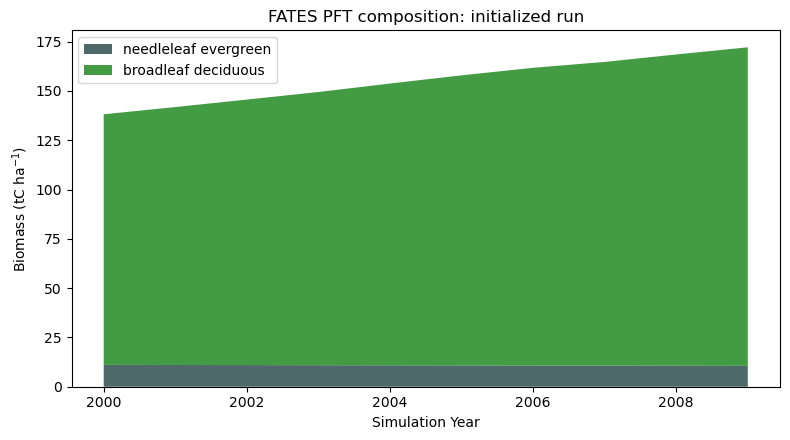

In [20]:
vegc_inv = annual_mean(ds_inv["FATES_VEGC_PF"], 10.0)  # tC/ha

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stackplot(vegc_inv.year,
             *[vegc_inv.sel(fates_levpft=pft).values for pft in active_pfts],
             labels=[v[0] for v in active_pfts.values()],
             colors=[v[1] for v in active_pfts.values()],
             alpha=0.85)
ax.set(xlabel="Simulation Year", ylabel="Biomass (tC ha$^{-1}$)",
       title="FATES PFT composition: initialized run")
ax.legend(loc="upper left")
fig.tight_layout()

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_bart_vegc_composition.png)

*<p style="text-align: left;"> Figure: Plotting solution. </p>*
    
</details>
</div>

**Question:** 

What do you notice about this plot? Which PFT is dominating? Does that match with the site description above?

#### Comparison to bare-ground run

With the above plot, we were sort of "cheating" at getting the composition right because we initialize the model with actual inventory data. Let's also look at our bareground run and see how that compares:

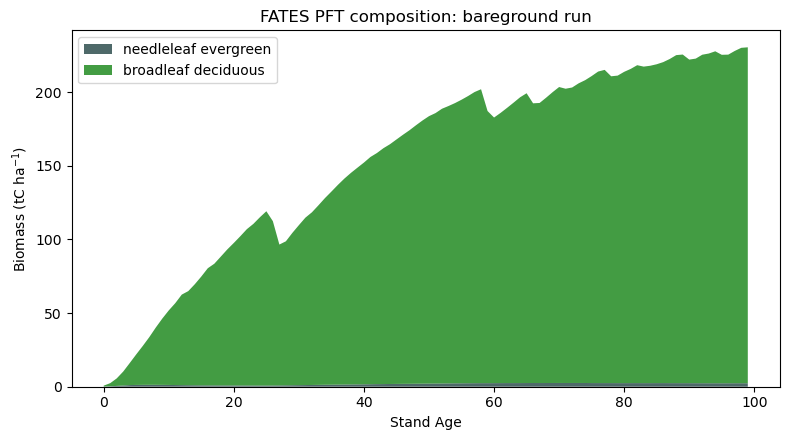

In [21]:
vegc_bg = annual_mean(ds_bg["FATES_VEGC_PF"], 10.0)  # tC/ha

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stackplot(np.arange(len(vegc_bg.year)),
             *[vegc_bg.sel(fates_levpft=pft).values for pft in active_pfts],
             labels=[v[0] for v in active_pfts.values()],
             colors=[v[1] for v in active_pfts.values()],
             alpha=0.85)
ax.set(xlabel="Stand Age", ylabel="Biomass (tC ha$^{-1}$)",
       title="FATES PFT composition: bareground run")
ax.legend(loc="upper left")
fig.tight_layout()

<div class="alert alert-success">   
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_bart_vegc_composition.png)

*<p style="text-align: left;"> Figure: Plotting solution. </p>*
    
</details>
</div>

---
### 3.3. Anatomy of a FATES forest

Next, let's look at size structure over time, using our multiplexed variable `FATES_NPLANT_SZPF`. First we will "deduplex" it and then sum across the `fates_levpft` dimension to look at total size structure over time. We'll take a look at the inventory-initialized simulation.

In [279]:
nplant = deduplex(ds_inv, ds_inv["FATES_NPLANT_SZPF"], 'scls', 'pft')
total = annual_mean(nplant.sum("fates_levpft"), 1e4)  # plants/ha

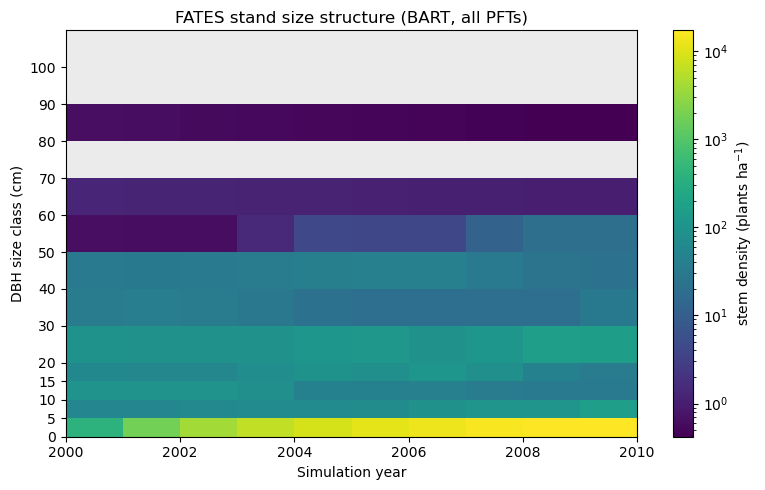

In [305]:
fig, ax = plt.subplots(figsize=(8, 5))

edges = ds_inv["fates_levscls"].values
y_edges = np.append(edges, edges[-1] + (edges[-1] - edges[-2]))
years = total.year
x_edges = np.append(years, years[-1] + 1)

vals = total.transpose("fates_levscls", "year").values
vmin = np.nanmin(vals[vals > 0])

cmap = plt.cm.viridis.copy()
cmap.set_bad("0.92")
mesh = ax.pcolormesh(
    x_edges, y_edges, np.ma.masked_less_equal(vals, 0),
    norm=mcolors.LogNorm(vmin=vmin, vmax=np.nanmax(vals)),
    cmap=cmap, shading="flat",
)
ax.set(xlabel="Simulation year", ylabel="DBH size class (cm)",
       title="FATES stand size structure (BART, all PFTs)")
ax.set_yticks(edges)
fig.colorbar(mesh, ax=ax, label="stem density (plants ha$^{-1}$)")
fig.tight_layout()
# plt.savefig("../../../images/diagnostics/clm_ctsm/fates_bart_stand_structure.png", bbox_inches="tight")

<div class="alert alert-success">
<details>
<summary><font face="Times New Roman">Click here for the solution</font></summary><br>

![plot example](../../../images/diagnostics/clm_ctsm/fates_bart_stand_structure.png)

*<p style="text-align: left;"> Figure: Plotting solution. </p>*
    
</details>
</div>

In [202]:
canopy = annual_mean(deduplex(ds_bart, ds_bart["FATES_NPLANT_CANOPY_SZPF"], 'scls', 'pft').sum("fates_levpft"), 1e4)
ustory = annual_mean(deduplex(ds_bart, ds_bart["FATES_NPLANT_USTORY_SZPF"], 'scls', 'pft').sum("fates_levpft"), 1e4)

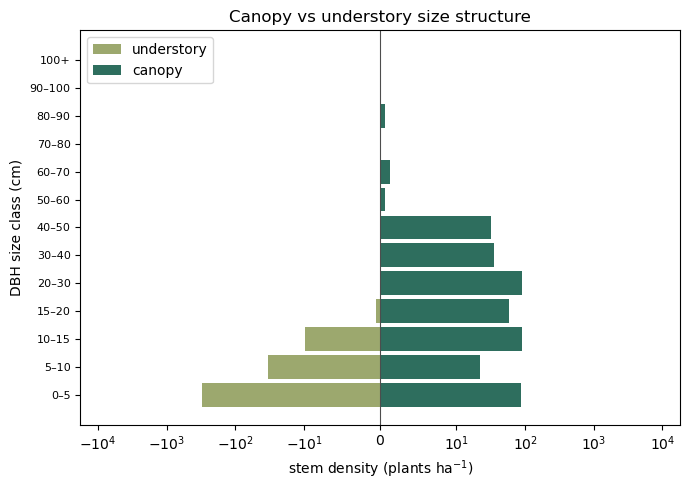

In [239]:
def draw_pyramid(ax, yr):
    """Mirrored size pyramid at year index yr: understory left, canopy right."""
    ax.barh(y, -ustory.isel(year=yr).values, height=0.85,
            color=LAYER_COLORS["understory"], label="understory")
    ax.barh(y,  canopy.isel(year=yr).values, height=0.85,
            color=LAYER_COLORS["canopy"], label="canopy")
    ax.axvline(0, color="0.3", lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(scls_labels, fontsize=8)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):g}"))


edges = ds_bart["fates_levscls"].values
scls_labels = [f"{int(edges[i])}–{int(edges[i+1])}" if i+1 < len(edges)
               else f"{int(edges[i])}+" for i in range(len(edges))]

LAYER_COLORS = {"understory": "#9CA86E", "canopy": "#2E6E5E"}
y = np.arange(len(edges))
xmax = max(float(canopy.max()), float(ustory.max())) * 1.05

fig, ax = plt.subplots(figsize=(7, 5))
draw_pyramid(ax, 0)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlim(-xmax, xmax)
ax.set(xlabel="stem density (plants ha$^{-1}$)", ylabel="DBH size class (cm)",
       title="Canopy vs understory size structure")
ax.legend(loc="upper left")
fig.tight_layout()

### 3.x Building a layered canopy
FATES doesn't model the canopy as a single slab. Following the Perfect Plasticity Approximation, it sorts crowns into discrete layers: a top canopy in full sun, and understory layers beneath. A young open stand has only a top layer — there's room for every crown in the sun. Once crown area fills the patch and the top canopy closes, newly there's no room up top, and FATES begins placing trees in a second, shaded layer. Splitting LAI by layer lets us watch that second layer appear.

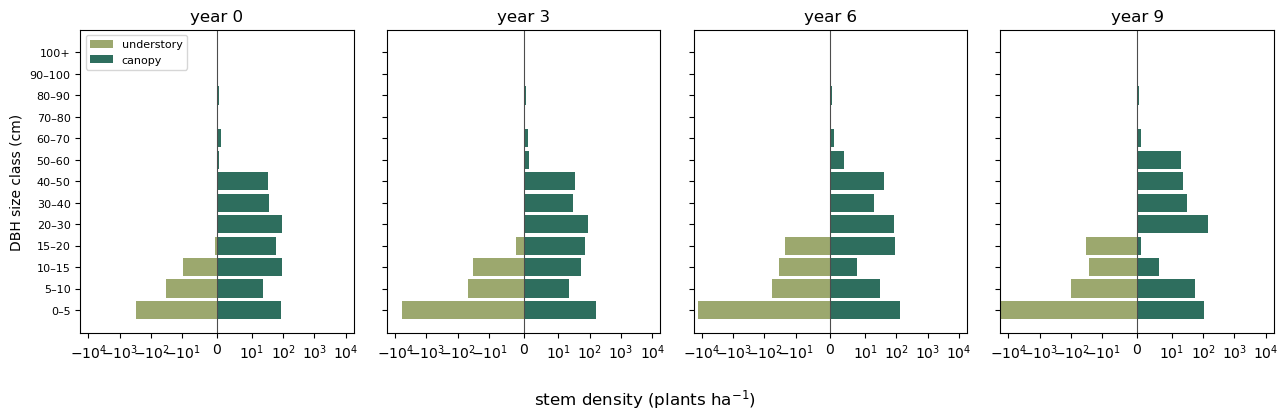

In [219]:
ts = [0, 3, 6, 9]
fig, axes = plt.subplots(1, len(ts), figsize=(13, 4.2), sharey=True)
for ax, t in zip(axes, ts):
    draw_pyramid(ax, t)
    ax.set_xscale("symlog", linthresh=10)
    ax.set_xlim(-xmax, xmax)
    ax.set_title(f"year {t}")
axes[0].set_ylabel("DBH size class (cm)")
axes[0].legend(loc="upper left", fontsize=8)
fig.supxlabel("stem density (plants ha$^{-1}$)")
fig.tight_layout()

In [268]:
lai_can = ds_bart.FATES_LAI_CANOPY_SZ.sum(dim='fates_levscls')
lai_ust = ds_bart.FATES_LAI_USTORY_SZ.sum(dim='fates_levscls')

peak_can = lai_can.groupby("time.year").max()
peak_ust = lai_ust.groupby("time.year").max()
years = peak_can["year"].values

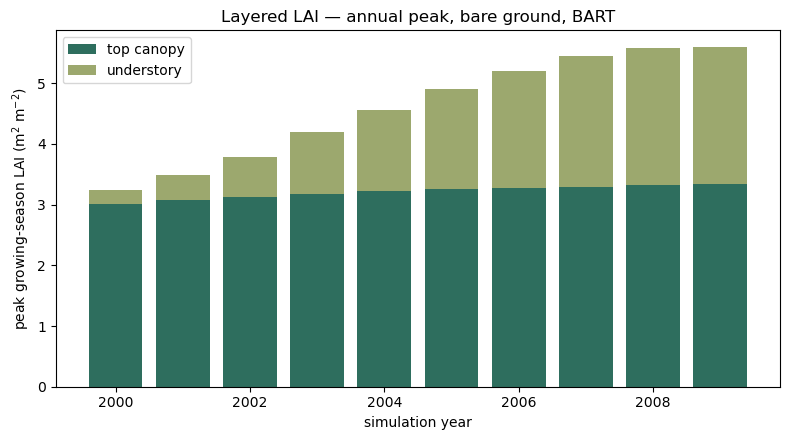

In [270]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(years, peak_can.values, color=LAYER_COLORS["canopy"], label="top canopy")
ax.bar(years, peak_ust.values, bottom=peak_can.values,
       color=LAYER_COLORS["understory"], label="understory")
ax.set(xlabel="simulation year", ylabel="peak growing-season LAI (m$^2$ m$^{-2}$)",
       title="Layered LAI — annual peak, bare ground, BART")
ax.legend(loc="upper left")
fig.tight_layout()

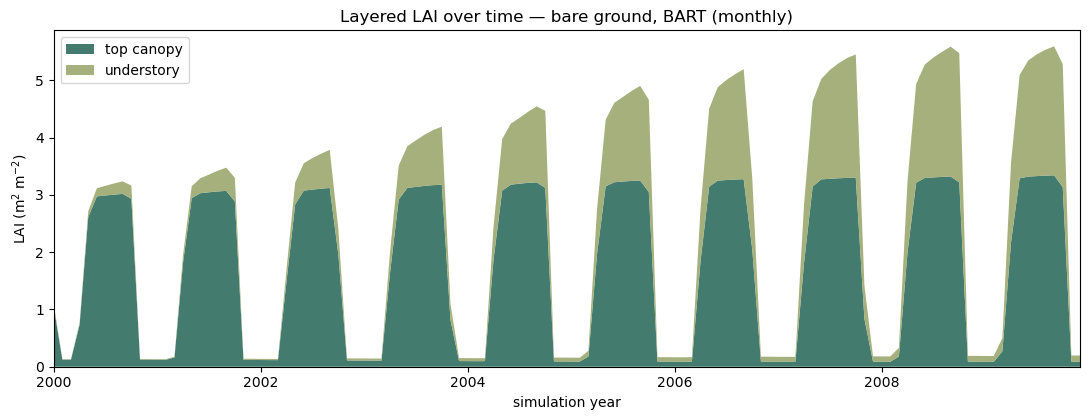

In [271]:
tyear = ds_bart["time"].dt.year + (ds_bart["time"].dt.month - 1) / 12

fig, ax = plt.subplots(figsize=(11, 4.3))
ax.stackplot(tyear.values, lai_can.values, lai_ust.values,
             labels=["top canopy", "understory"],
             colors=[LAYER_COLORS["canopy"], LAYER_COLORS["understory"]], alpha=0.9)
ax.set(xlabel="simulation year", ylabel="LAI (m$^2$ m$^{-2}$)",
       title="Layered LAI over time — bare ground, BART (monthly)")
ax.legend(loc="upper left"); ax.margins(x=0)
fig.tight_layout()

In [299]:
promo = ds_inv["FATES_PROMOTION_RATE_SZ"].sel(fates_levscls=slice(0, 100)).sum("fates_levscls") * 1e4
demo = ds_inv["FATES_DEMOTION_RATE_SZ"].sel(fates_levscls=slice(0, 100)).sum("fates_levscls") * 1e4

tyear = ds_inv["time"].dt.year + (ds_inv["time"].dt.month - 1) / 12

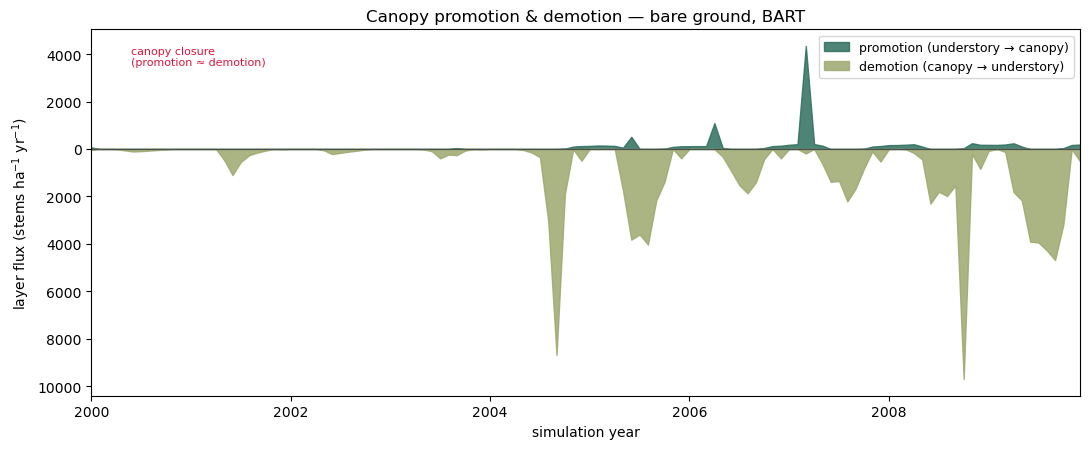

In [300]:
t = tyear.values
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.fill_between(t, 0,  promo.values, color=LAYER_COLORS["canopy"], alpha=0.85,
                label="promotion (understory → canopy)")
ax.fill_between(t, 0, -demo.values, color=LAYER_COLORS["understory"], alpha=0.85,
                label="demotion (canopy → understory)")
ax.axhline(0, color="0.3", lw=0.8)

diff = (promo.values - demo.values)
sign_change = np.where(np.diff(np.sign(diff)))[0]
if sign_change.size:
    xc = t[sign_change[0]]
    ax.axvline(xc, color="crimson", ls="--", lw=1.2)
    ax.annotate("canopy closure\n(promotion ≈ demotion)", xy=(xc, ax.get_ylim()[1]*0.7),
                xytext=(xc + 0.4, ax.get_ylim()[1]*0.7), fontsize=8, color="crimson")

ax.set(xlabel="simulation year", ylabel="layer flux (stems ha$^{-1}$ yr$^{-1}$)",
       title="Canopy promotion & demotion — bare ground, BART")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{abs(v):g}"))
ax.legend(loc="upper right", fontsize=9)
ax.margins(x=0)
fig.tight_layout()

In [34]:
MORT_VARS = {
    "background":        "FATES_MORTALITY_BACKGROUND_SZ",
    "freezing":          "FATES_MORTALITY_FREEZING_SZ",
    "carbon starvation": "FATES_MORTALITY_CSTARV_SZ",
    "hydraulic failure": "FATES_MORTALITY_HYDRAULIC_SZ",
    "impact":            "FATES_MORTALITY_IMPACT_SZ",
    "senescence":        "FATES_MORTALITY_SENESCENCE_SZ",
    "termination":       "FATES_MORTALITY_TERMINATION_SZ",
}

In [323]:
mort_total = {label: ds_inv[v].sel(fates_levscls=slice(5, 100)).sum("fates_levscls")
              for label, v in MORT_VARS.items()}

mort_total_annual = {k: annual_mean(v) for k, v in mort_total.items()}
years = next(iter(mort_total_annual.values()))["year"].values

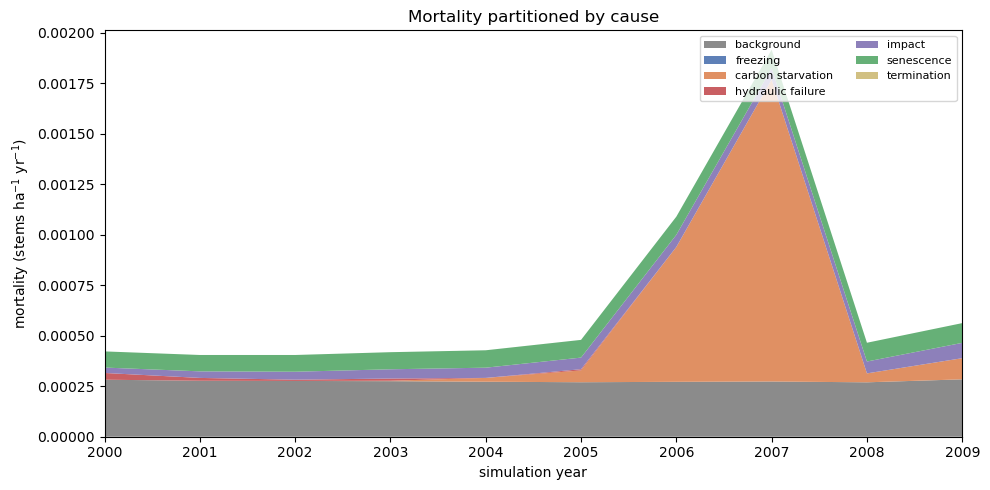

In [324]:
CAUSE_COLORS = {
    "background": "#7f7f7f",
    "freezing": "#4C72B0",
    "carbon starvation": "#DD8452",
    "hydraulic failure": "#C44E52",
    "impact": "#8172B3",
    "senescence": "#55A868",
    "termination": "#CCB974",
}
order = [k for k in CAUSE_COLORS if k in mort_total_annual]   # fixed stack order

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(years, *[mort_total_annual[k].values for k in order], labels=order,
             colors=[CAUSE_COLORS[k] for k in order], alpha=0.9)
ax.set(xlabel="simulation year", ylabel="mortality (stems ha$^{-1}$ yr$^{-1}$)",
       title="Mortality partitioned by cause")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.margins(x=0)
fig.tight_layout()

In [361]:
mort_by_size = {label: annual_mean(ds_inv[v].sel(fates_levscls=slice(5, None)), 1e4).mean(dim='year')
              for label, v in MORT_VARS.items()}

order  = [k for k in CAUSE_COLORS if k in mort_by_size]
edges  = mort_by_size[order[0]]["fates_levscls"].values
labels = [f"{int(edges[i])}–{int(edges[i+1])}" if i+1 < len(edges)
          else f"{int(edges[i])}+" for i in range(len(edges))]
y = np.arange(len(edges))

M = np.vstack([mort_by_size[k].values for k in order])
total = M.sum(axis=0)
frac  = np.divide(M, total, out=np.full_like(M, np.nan), where=total > 0)

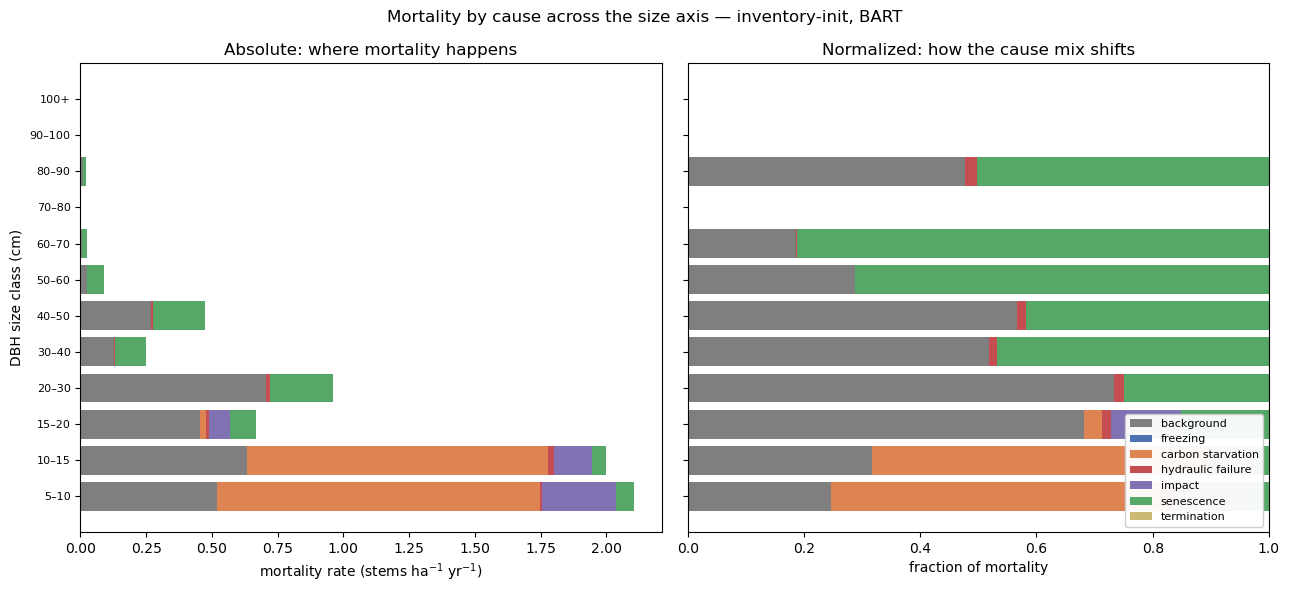

In [362]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, data, xlab in [(axes[0], M,    "mortality rate (stems ha$^{-1}$ yr$^{-1}$)"),
                       (axes[1], frac, "fraction of mortality")]:
    left = np.zeros(len(edges))
    for ci, k in enumerate(order):
        ax.barh(y, np.nan_to_num(data[ci]), left=np.nan_to_num(left),
                height=0.8, color=CAUSE_COLORS[k], label=k)
        left = left + np.nan_to_num(data[ci])
    ax.set_xlabel(xlab)

axes[0].set_yticks(y)
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_ylabel("DBH size class (cm)")
axes[0].set_title("Absolute: where mortality happens")
axes[1].set_title("Normalized: how the cause mix shifts")
axes[1].set_xlim(0, 1)
axes[1].legend(loc="lower right", fontsize=8, framealpha=0.95)
fig.suptitle("Mortality by cause across the size axis — inventory-init, BART", y=0.98)
fig.tight_layout()

In [54]:
nplant_sz = deduplex(ds_inv, ds_inv["FATES_NPLANT_SZPF"], 'scls', 'pft').sum('fates_levpft')

In [56]:
# GROWTH: DDBH_CANOPY is _SZPF and abundance-weighted, so normalize by canopy
# stem count to recover a per-tree increment. (Same scpf_to_scls_pft helper.)
ddbh = annual_mean(deduplex(ds_inv, ds_inv["FATES_DDBH_CANOPY_SZPF"], 'scls', 'pft')).sum("fates_levpft")
ncan = annual_mean(deduplex(ds_inv, ds_inv["FATES_NPLANT_CANOPY_SZPF"], 'scls', 'pft')).sum("fates_levpft")

growth = xr.where(ncan > 0, ddbh / ncan, np.nan).sel(fates_levscls=slice(5, None)).mean(dim='year')   # cm/yr per tree

# MORTALITY: total across causes, _SZ (size only), averaged over time
mort = sum(annual_mean(ds_inv[v])/annual_mean(nplant_sz) for v in MORT_VARS.values()).sel(fates_levscls=slice(5, None)).mean(dim='year')

edges  = growth["fates_levscls"].values
labels = [f"{int(edges[i])}–{int(edges[i+1])}" if i+1 < len(edges)
          else f"{int(edges[i])}+" for i in range(len(edges))]
y = np.arange(len(edges))

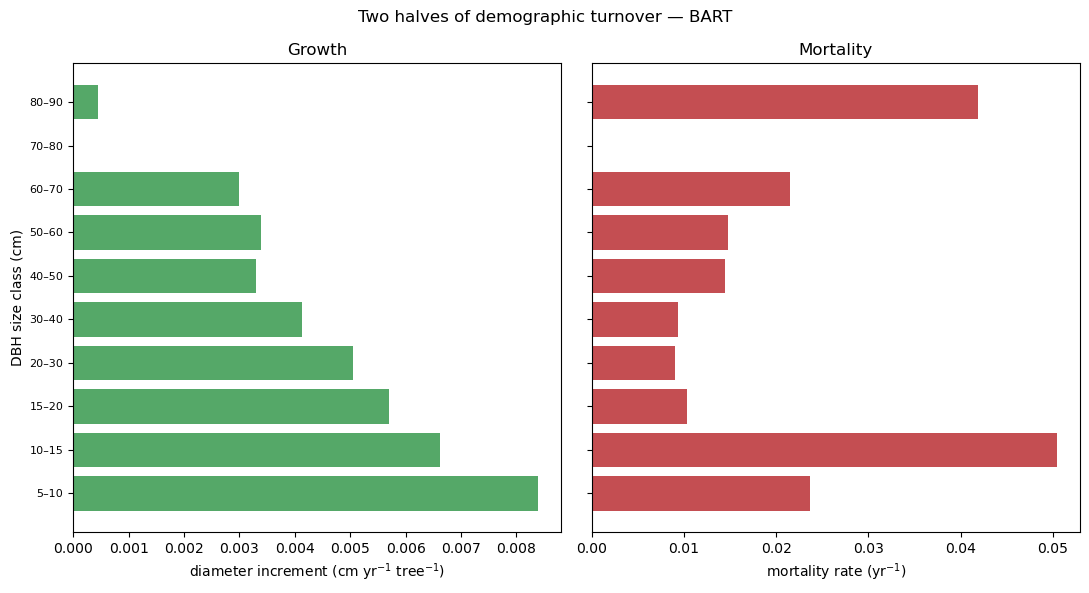

In [57]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 6), sharey=True)

a0.barh(y, growth.values, color="#55A868", height=0.8)
a0.set(xlabel="diameter increment (cm yr$^{-1}$ tree$^{-1}$)", ylabel="DBH size class (cm)",
       title="Growth")
a0.set_yticks(y); a0.set_yticklabels(labels, fontsize=8)

a1.barh(y, mort.values, color="#C44E52", height=0.8)
a1.set(xlabel="mortality rate (yr$^{-1}$)", title="Mortality")

fig.suptitle("Two halves of demographic turnover — BART", y=0.98)
fig.tight_layout()

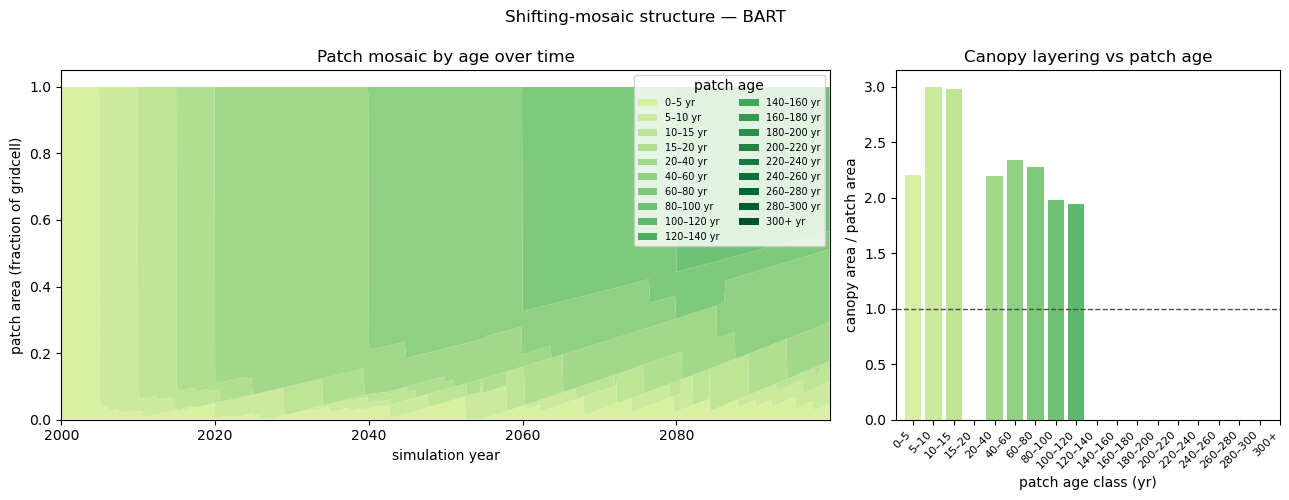

In [81]:
pa = ds_bg["FATES_PATCHAREA_AP"]    # (time, fates_levage) — patch area by age class
ca = ds_bg["FATES_CANOPYAREA_AP"]   # canopy (crown) area by age class

closure = xr.where(pa > 0, ca / pa, np.nan).isel(time=-1).values
ages_present = ~np.isnan(closure)

edges = ds_bg["fates_levage"].values
na = len(edges)
labels = [f"{int(edges[i])}–{int(edges[i+1])}" if i+1 < na else f"{int(edges[i])}+"
          for i in range(na)]

import matplotlib.cm as cm
colors = cm.YlGn(np.linspace(0.25, 0.95, na))     # young -> old = light -> dark
tyear = ds_bg["time"].dt.year + (ds_bg["time"].dt.month - 1) / 12

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})

# (1) the mosaic shifting over time
a0.stackplot(tyear.values, *[pa.isel(fates_levage=i).values for i in range(na)],
             colors=colors, labels=[f"{l} yr" for l in labels])
a0.set(xlabel="simulation year", ylabel="patch area (fraction of gridcell)",
       title="Patch mosaic by age over time")
a0.margins(x=0)
a0.legend(loc="upper right", fontsize=7, title="patch age", ncol=2)

# (2) canopy closure as a function of patch age (final year)

a1.bar(np.arange(na)[ages_present], closure[ages_present], color=colors[ages_present])
a1.axhline(1.0, color="0.3", ls="--", lw=1)          # single closed layer
a1.set(xticks=range(na), xlabel="patch age class (yr)",
       ylabel="canopy area / patch area", title="Canopy layering vs patch age")
a1.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
fig.suptitle("Shifting-mosaic structure — BART", y=0.99)
fig.tight_layout()
plt.savefig('fig.png')

In [74]:
print("patch sum :", float(pa.isel(time=-1).sum()),  pa.attrs.get("units"))
print("canopy sum:", float(ca.isel(time=-1).sum()),  ca.attrs.get("units"))

patch sum : 1.0 m2 m-2
canopy sum: 2.224168062210083 m2 m-2


In [76]:
print([v for v in ds_bg.data_vars if v.endswith("_AP")])

['FATES_CANOPYAREA_AP', 'FATES_PATCHAREA_AP']


In [73]:
closure = xr.where(pa > 0, ca / pa, np.nan).isel(time=-1).values
closure

array([2.2071977, 2.9975953, 2.9824235,       nan, 2.1977875, 2.3359   ,
       2.2767591, 1.9801043, 1.9414368,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan], dtype=float32)

### 3.x An emergent law: self-thinning
Everything so far has been structure FATES tracks directly. This last plot is different — it's a community-scale pattern that no one coded into FATES, yet it appears anyway. As a crowded young stand grows, competition kills the losers, so stem density falls while the survivors get larger. Ecologists have long observed that mean plant mass and density trade off along a remarkably consistent slope — the −3/2 self-thinning law (Yoda 1963). If FATES's demography is behaving like a real forest, a bare-ground stand should trace that same line on its own.

In [103]:
nplant_sz = deduplex(ds_bg, ds_bg["FATES_NPLANT_SZPF"], 'scls', 'pft').sum('fates_levpft')

In [106]:

N_m2 = annual_mean(nplant_sz.sel(fates_levscls=slice(0, None))).sum("fates_levscls")#.values   # total stems, /m2
B = annual_mean(ds_bg["FATES_VEGC_PF"]).sum("fates_levpft")#.values
yr = B.year
# Drop un-established steps: mean mass = B/N is undefined when the stand is empty.
ok   = (N_m2.values > 1e-4) & (B > 0)
N    = N_m2.values[ok] * 1e4          # stems/ha
wbar = B.values[ok] / N_m2.values[ok]        # kg C per stem
yr   = yr[ok]

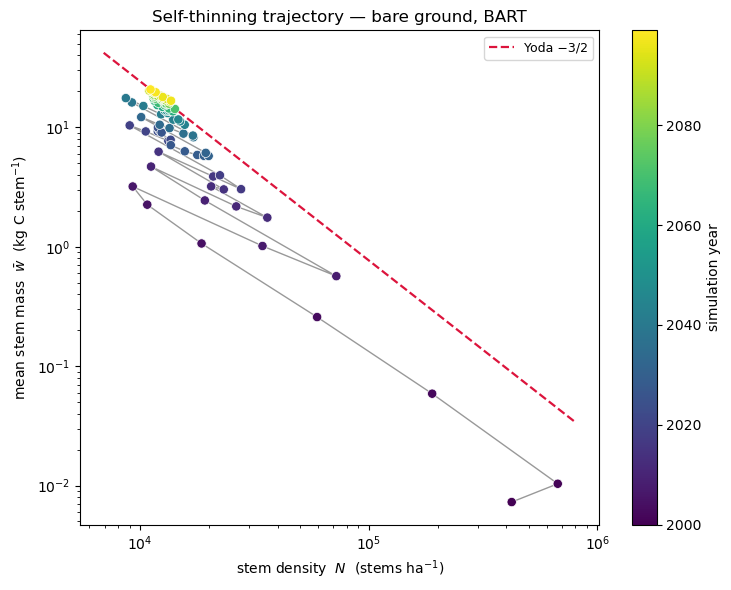

In [107]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(N, wbar, color="0.6", lw=1, zorder=2)                       # trajectory
sc = ax.scatter(N, wbar, c=yr, cmap="viridis", s=45, zorder=3,
                edgecolor="white", linewidth=0.5)
ax.set(xscale="log", yscale="log",
       xlabel=r"stem density  $N$  (stems ha$^{-1}$)",
       ylabel=r"mean stem mass  $\bar{w}$  (kg C stem$^{-1}$)",
       title="Self-thinning trajectory — bare ground, BART")

# # reference slopes, anchored through the most-developed (thinned) point
a = int(np.argmax(wbar))
xs = np.array([N.min()*0.8, N.max()*1.2])
for slope, col, ls, lab in [(-1.5, "crimson", "--", "Yoda −3/2")]:
    ax.plot(xs, wbar[a]*(xs/N[a])**slope, ls, color=col, lw=1.6, label=lab, zorder=1)

fig.colorbar(sc, ax=ax, label="simulation year")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()